## Notebook for identifying TF communities in the Norman dataset

In [1]:
# set up
import math
import pickle
import os
import requests

import anndata
import gseapy as gp
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from gseapy.parser import DEFAULT_CACHE_PATH
from scipy.stats import false_discovery_control, norm
from sklearn.mixture import GaussianMixture

from gcrl.grn import (
    build_cluster_gene_sets,
    build_coassociation_matrix,
    build_tf_tf_cotarget_layer,
    build_tf_tf_regulatory_layer,
    community_stats,
    consensus_partition_majority_vote,
    compute_go_levels,
    extract_go_ids_from_terms,
    filter_cluster_specific_terms,
    filter_gene_sets_by_size_and_level,
    filter_trivial_partitions,
    partition_stability_diagnostics,
    plot_enrichment_dotplot,
    plot_tf_tf_communities,
    prettify_go_term,
    run_ora_for_clusters,
    run_single_layer_leiden_cot,
    run_single_layer_leiden_reg,
)

In [2]:
# Control parameters
data_folder       = '../../../data/real/Norman2019/'   # path to data folder
results_folder    = '../../../data/real/Norman2019/GRN/'  # path to results folder
figures_folder    = results_folder + 'figures/'        # output folder for saved plots
significance_level = 0.05   # FDR threshold for GRN edge filtering
min_size          = 5       # minimum cluster size (smaller clusters are merged)
top_percentage    = 1.0     # fraction of top-ranked edges to retain

# 3. Hyperparameter grids (tune as needed)
# NOTE: Using ONLY g_reg (regulatory layer), NO cotarget layer
# gamma_reg_list = [1.0, 1.1, 1.2, 1.25, 1.3, 1.4, 1.5] # 1.4
# gamma_reg_list = [0.9, 1.0, 1.1] # 1.0
# gamma_reg_list = [0.9] # 0.9
# gamma_reg_list = [1.5, 1.6, 1.7, 1.8, 1.9, 2.0, 2.1, 2.2, 2.3, 2.4, 2.5] # 2.5
gamma_reg_list = list(np.round(np.arange(0.8, 2.1, 0.1), 1))
n_seeds  = 1000
best_key = 1.1    # best gamma_reg (chosen from stability diagnostics)

# HVG universe for ORA: the 5,000 most variable genes used to build the GRN.
# Loaded once here so it is available throughout the notebook.
adata     = anndata.read_h5ad(data_folder + 'Norman2019_raw.h5ad')
hvg_names = list(adata.var_names)  # all 5,000 HVGs
del adata  # free memory; only the gene names are needed

# Helper: save a figure as PNG and SVG, then display it
os.makedirs(figures_folder, exist_ok=True)

def save_figure(fig, name):
    """Save fig to figures_folder as <name>.png and <name>.svg, then show."""
    fig.savefig(figures_folder + name + '.png', dpi=150, bbox_inches='tight')
    fig.savefig(figures_folder + name + '.svg', bbox_inches='tight')
    plt.show()
    print(f'Saved: {figures_folder}{name}.png / .svg')


### Loading and filtering GRN

In [3]:
#Load GRN 
raw_grn = pd.read_csv(results_folder + "raw_GRN.csv", index_col=0)

#Drop NA values in p-value column
raw_grn = raw_grn.dropna(subset=["p"])

#FDR filtering and only leaving adj p-values values less than 0.05
raw_grn.loc[:, 'adjp'] = false_discovery_control(raw_grn['p'].values, method='bh')
filtered_grn = raw_grn[raw_grn['adjp'] <= significance_level].copy()

# Sort by absolute coefficient descending
filtered_grn = filtered_grn.sort_values(by='coef_abs', ascending=False).reset_index(drop=True)


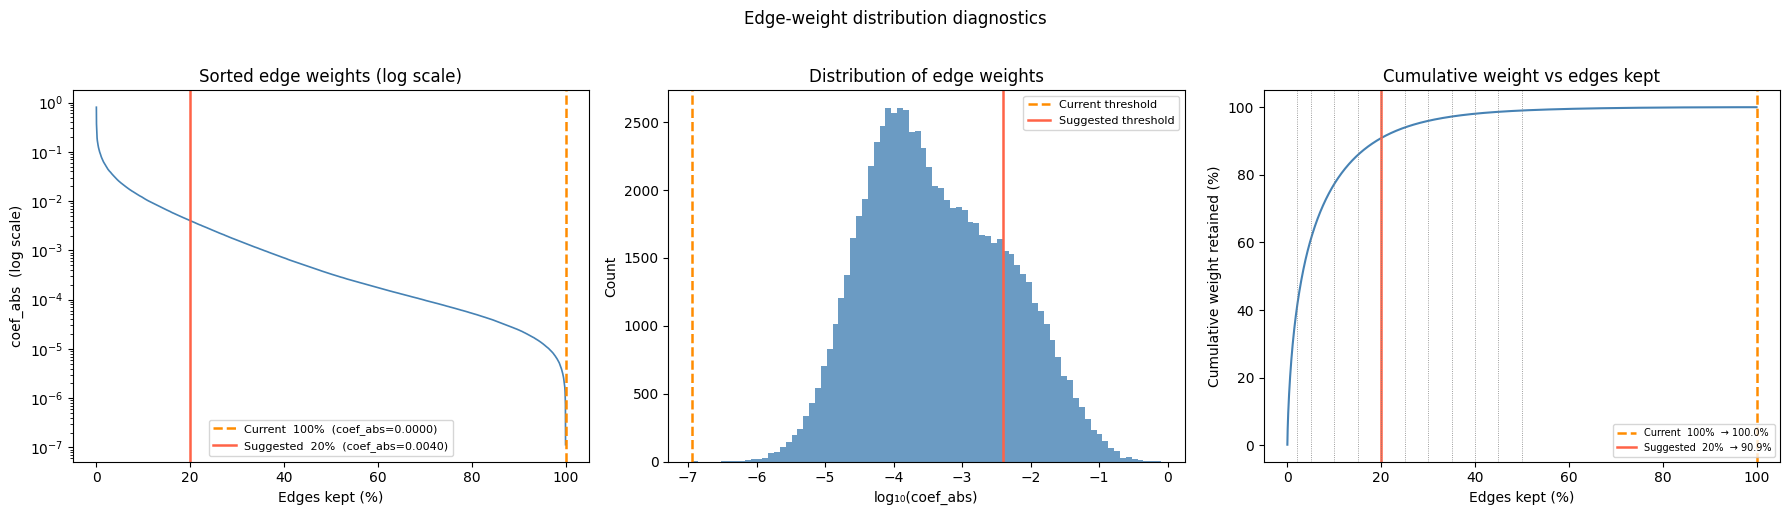

Saved: ../../../data/real/Norman2019/GRN/figures/edge_weight_diagnostics.png / .svg
   Threshold   N edges    coef_abs ≥   Cumul. weight    Δ weight
--------------------------------------------------------------------
          2%      1531        0.0524           40.4%           —
          5%      3828        0.0245           61.0%      +20.6%
         10%      7657        0.0117           77.3%      +16.4%
         15%     11486        0.0066           85.8%       +8.5%
         20%     15315        0.0040           90.9%       +5.0%  ← suggested
         25%     19144        0.0025           94.0%       +3.1%
         30%     22973        0.0016           96.0%       +2.0%
         35%     26801        0.0011           97.2%       +1.3%
         40%     30630        0.0007           98.1%       +0.8%
         45%     34459        0.0005           98.6%       +0.6%
         50%     38288        0.0003           99.0%       +0.4%

Suggested top_percentage = 0.2  (first step where Δ c

In [4]:
# Edge-weight threshold diagnostics
# -----------------------------------
# GRN edge-weight distributions are typically heavy-tailed: the diagonal-distance
# elbow on the raw curve always snaps to the very first steep drop and is not useful.
# Instead we show three complementary views to help choose top_percentage:
#
#   1. Log-scale sorted weights  – reveals natural breaks / slope changes in the tail
#   2. Histogram of log10(coef_abs) – shows the shape of the distribution
#   3. Cumulative % of total weight retained vs edges kept – balances coverage vs sparsity

weights_sorted = filtered_grn['coef_abs'].values   # already sorted descending
n = len(weights_sorted)
pct_axis = np.linspace(0, 100, n)
cum_weight = np.cumsum(weights_sorted) / weights_sorted.sum() * 100

# Candidate thresholds and their cumulative weight
candidates = [0.02, 0.05, 0.10, 0.15, 0.20, 0.25, 0.30, 0.35, 0.40, 0.45, 0.50]
cw_vals = [cum_weight[int(p * n) - 1] for p in candidates]

# Find the first candidate where the cumulative weight gain over the previous step < 5%
suggested_pct = candidates[-1]
for i in range(1, len(candidates)):
    if cw_vals[i] - cw_vals[i - 1] < 5.0:
        suggested_pct = candidates[i - 1]
        break

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# --- 1. Log-scale sorted weights ---
axes[0].semilogy(pct_axis, weights_sorted, color='steelblue', lw=1.2)
axes[0].axvline(top_percentage * 100, color='darkorange', lw=1.8, linestyle='--',
                label=f'Current  {top_percentage*100:.0f}%'
                      f'  (coef_abs={weights_sorted[int(top_percentage*n)-1]:.4f})')
axes[0].axvline(suggested_pct * 100, color='tomato', lw=1.8, linestyle='-',
                label=f'Suggested  {suggested_pct*100:.0f}%'
                      f'  (coef_abs={weights_sorted[int(suggested_pct*n)-1]:.4f})')
axes[0].set_xlabel('Edges kept (%)')
axes[0].set_ylabel('coef_abs  (log scale)')
axes[0].set_title('Sorted edge weights (log scale)')
axes[0].legend(fontsize=8)

# --- 2. Histogram of log10(coef_abs) ---
log_w = np.log10(weights_sorted[weights_sorted > 0])
axes[1].hist(log_w, bins=80, color='steelblue', edgecolor='none', alpha=0.8)
axes[1].axvline(np.log10(weights_sorted[int(top_percentage * n) - 1]),
                color='darkorange', lw=1.8, linestyle='--', label='Current threshold')
axes[1].axvline(np.log10(weights_sorted[int(suggested_pct * n) - 1]),
                color='tomato', lw=1.8, linestyle='-', label='Suggested threshold')
axes[1].set_xlabel('log₁₀(coef_abs)')
axes[1].set_ylabel('Count')
axes[1].set_title('Distribution of edge weights')
axes[1].legend(fontsize=8)

# --- 3. Cumulative weight with gain bars ---
axes[2].plot(pct_axis, cum_weight, color='steelblue', lw=1.5)
axes[2].axvline(top_percentage * 100, color='darkorange', lw=1.8, linestyle='--',
                label=f'Current  {top_percentage*100:.0f}%  → {cum_weight[int(top_percentage*n)-1]:.1f}%')
axes[2].axvline(suggested_pct * 100, color='tomato', lw=1.8, linestyle='-',
                label=f'Suggested  {suggested_pct*100:.0f}%  → {cum_weight[int(suggested_pct*n)-1]:.1f}%')
for pct in candidates:
    idx = int(pct * n) - 1
    axes[2].axvline(pct * 100, color='gray', lw=0.6, linestyle=':')
axes[2].set_xlabel('Edges kept (%)')
axes[2].set_ylabel('Cumulative weight retained (%)')
axes[2].set_title('Cumulative weight vs edges kept')
axes[2].legend(fontsize=7)

plt.suptitle('Edge-weight distribution diagnostics', y=1.02)
plt.tight_layout()
save_figure(fig, 'edge_weight_diagnostics')

# Summary table
print(f"{'Threshold':>12}  {'N edges':>8}  {'coef_abs ≥':>12}  {'Cumul. weight':>14}  {'Δ weight':>10}")
print("-" * 68)
for i, pct in enumerate(candidates):
    idx = max(0, int(pct * n) - 1)
    delta = f"{cw_vals[i] - cw_vals[i-1]:+.1f}%" if i > 0 else "    —"
    marker = "  ← suggested" if pct == suggested_pct else ""
    print(f"{pct*100:>11.0f}%  {idx+1:>8d}  {weights_sorted[idx]:>12.4f}  "
          f"{cw_vals[i]:>13.1f}%  {delta:>10}{marker}")

print(f"\nSuggested top_percentage = {suggested_pct}"
      f"  (first step where Δ cumulative weight < 5%)")

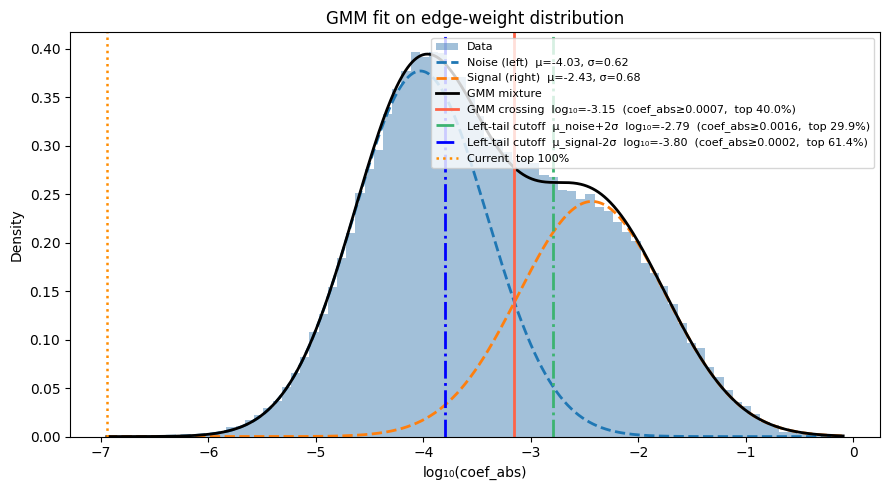

Saved: ../../../data/real/Norman2019/GRN/figures/gmm_threshold.png / .svg
GMM crossing      → coef_abs ≥ 0.0007  (top 40.0%,  30640 edges)
Left-tail cutoff  → coef_abs ≥ 0.0016  (top 29.9%,  22885 edges)  [noise μ - 2σ = -4.03 - 2×0.62]
Current setting   → coef_abs ≥ 0.0000  (top 100%,  76577 edges)


In [5]:
# GMM threshold: fit 2 Gaussians on log10(coef_abs), find the crossing point
# ---------------------------------------------------------------------------
# Two thresholds are computed:
#   1. GMM crossing  : where signal PDF overtakes noise PDF (between the two means).
#      Keeps only edges that are more likely signal than noise.
#   2. Left-tail cutoff: mean of the noise Gaussian + n_sigma * std.
#      Removes only the very weakest edges (deep left tail of the noise component).
#      More permissive than the crossing — useful as a soft floor before ORA.

n_sigma_tail = 2 

log_w = np.log10(weights_sorted[weights_sorted > 0])

# Fit 2-component GMM
gmm = GaussianMixture(n_components=2, random_state=42)
gmm.fit(log_w.reshape(-1, 1))

# Sort components by mean so component 0 = noise (left), 1 = signal (right)
order = np.argsort(gmm.means_.ravel())
means  = gmm.means_.ravel()[order]
stds   = np.sqrt(gmm.covariances_.ravel())[order]
weights_gmm = gmm.weights_[order]

# --- Threshold 1: crossing point between the two weighted Gaussians ---
# Solve: w0 * N(x; mu0, s0) = w1 * N(x; mu1, s1)  on a fine grid
x_grid = np.linspace(log_w.min(), log_w.max(), 10_000)
pdf0 = weights_gmm[0] * norm.pdf(x_grid, means[0], stds[0])
pdf1 = weights_gmm[1] * norm.pdf(x_grid, means[1], stds[1])

# Crossing between the two means = the valley
between = (x_grid > means[0]) & (x_grid < means[1])
diff = pdf1[between] - pdf0[between]
sign_changes = np.where(np.diff(np.sign(diff)))[0]
if len(sign_changes) > 0:
    cross_log = x_grid[between][sign_changes[0]]
else:
    cross_log = x_grid[between][np.argmin(pdf0[between] + pdf1[between])]

cross_coef = 10 ** cross_log
gmm_pct = np.mean(weights_sorted >= cross_coef)
gmm_n   = int(gmm_pct * n)

# --- Threshold 2: left-tail cutoff (noise mean + n_sigma * noise std) ---
# This excludes only the deepest left tail of the noise component.
tail_log  = means[0] + n_sigma_tail * stds[0]
tail_coef = 10 ** tail_log
tail_pct  = np.mean(weights_sorted >= tail_coef)
tail_n    = int(tail_pct * n)

# --- Threshold 3: left-tail cutoff signal ---
tail_log_signal  = means[1] - n_sigma_tail * stds[1]
tail_coef_signal = 10 ** tail_log_signal
tail_pct_signal  = np.mean(weights_sorted >= tail_coef_signal)
tail_n_signal    = int(tail_pct_signal * n)

# --- Plot ---
fig, ax = plt.subplots(figsize=(9, 5))

ax.hist(log_w, bins=80, density=True, color='steelblue', alpha=0.5,
        edgecolor='none', label='Data')

x_plot = np.linspace(log_w.min(), log_w.max(), 1000)
for i, (m, s, w, lbl) in enumerate(zip(means, stds, weights_gmm,
                                        ['Noise (left)', 'Signal (right)'])):
    ax.plot(x_plot, w * norm.pdf(x_plot, m, s),
            lw=2, linestyle='--', label=f'{lbl}  μ={m:.2f}, σ={s:.2f}')

ax.plot(x_plot, (weights_gmm[0] * norm.pdf(x_plot, means[0], stds[0]) +
                 weights_gmm[1] * norm.pdf(x_plot, means[1], stds[1])),
        lw=2, color='black', label='GMM mixture')

ax.axvline(cross_log, color='tomato', lw=2, linestyle='-',
           label=f'GMM crossing  log₁₀={cross_log:.2f}'
                 f'  (coef_abs≥{cross_coef:.4f},  top {gmm_pct*100:.1f}%)')
ax.axvline(tail_log, color='mediumseagreen', lw=2, linestyle='-.',
           label=f'Left-tail cutoff  μ_noise+{n_sigma_tail}σ  log₁₀={tail_log:.2f}'
                 f'  (coef_abs≥{tail_coef:.4f},  top {tail_pct*100:.1f}%)')
ax.axvline(tail_log_signal, color='blue', lw=2, linestyle='-.',
           label=f'Left-tail cutoff  μ_signal-{n_sigma_tail}σ  log₁₀={tail_log_signal:.2f}'
                 f'  (coef_abs≥{tail_coef_signal:.4f},  top {tail_pct_signal*100:.1f}%)')
ax.axvline(np.log10(weights_sorted[int(top_percentage * n) - 1]),
           color='darkorange', lw=1.8, linestyle=':',
           label=f'Current  top {top_percentage*100:.0f}%')

ax.set_xlabel('log₁₀(coef_abs)')
ax.set_ylabel('Density')
ax.set_title('GMM fit on edge-weight distribution')
ax.legend(fontsize=8)
plt.tight_layout()
save_figure(fig, 'gmm_threshold')

print(f"GMM crossing      → coef_abs ≥ {cross_coef:.4f}  "
      f"(top {gmm_pct*100:.1f}%,  {gmm_n} edges)")
print(f"Left-tail cutoff  → coef_abs ≥ {tail_coef:.4f}  "
      f"(top {tail_pct*100:.1f}%,  {tail_n} edges)  "
      f"[noise μ - {n_sigma_tail}σ = {means[0]:.2f} - {n_sigma_tail}×{stds[0]:.2f}]")
print(f"Current setting   → coef_abs ≥ {weights_sorted[int(top_percentage*n)-1]:.4f}  "
      f"(top {top_percentage*100:.0f}%,  {int(top_percentage*n)} edges)")


In [6]:
# selecting top_percentage of top edges
num_top_edges = math.ceil(len(filtered_grn) * top_percentage)
current_grn = filtered_grn.iloc[:num_top_edges, :]

# print statistics
print(current_grn['source'].nunique(), current_grn['target'].nunique())
current_grn

141 2701


,source,target,coef_mean,coef_abs,p,-logp,adjp
0,JUND,HIST1H4C,8.047544e-01,8.047544e-01,1.398194e-13,12.854433,1.714543e-12
1,KLF1,HBZ,5.446500e-01,5.446500e-01,1.372758e-17,16.862406,1.212940e-15
2,CEBPB,HIST1H4C,5.004821e-01,5.004821e-01,1.081264e-06,5.966068,2.114018e-06
3,MEF2C,HIST1H4C,-4.741253e-01,4.741253e-01,1.250190e-14,13.903024,2.403039e-13
4,PITX1,HIST1H4C,4.606655e-01,4.606655e-01,5.195326e-10,9.284387,1.967101e-09
...,...,...,...,...,...,...,...
76572,ETS1,S100A6,-4.682975e-07,4.682975e-07,1.248373e-02,1.903656,1.538445e-02
76573,MYCN,C1QB,4.038104e-07,4.038104e-07,2.433904e-03,2.613696,3.205585e-03
76574,ETS1,MAP3K7CL,-3.477329e-07,3.477329e-07,2.214882e-02,1.654649,2.667023e-02
76575,KLF7,TSPAN16,3.067854e-07,3.067854e-07,9.894209e-03,2.004619,1.231039e-02


In [7]:
# Coverage diagnostics: how much of the original GRN survives thresholding?
# -------------------------------------------------------------------------
_before = filtered_grn
_after  = current_grn

n_edges_before   = len(_before)
n_edges_after    = len(_after)
n_tf_src_before  = _before['source'].nunique()
n_tf_src_after   = _after['source'].nunique()
n_target_before  = _before['target'].nunique()
n_target_after   = _after['target'].nunique()
n_unique_genes_before = pd.concat([_before['source'], _before['target']]).nunique()
n_unique_genes_after  = pd.concat([_after['source'],  _after['target']]).nunique()

print(f"{'Metric':<35} {'Before':>10} {'After':>10} {'Retained':>10}")
print("-" * 67)
print(f"{'Edges':<35} {n_edges_before:>10,} {n_edges_after:>10,} {n_edges_after/n_edges_before:>9.1%}")
print(f"{'TF sources':<35} {n_tf_src_before:>10,} {n_tf_src_after:>10,} {n_tf_src_after/n_tf_src_before:>9.1%}")
print(f"{'Target genes':<35} {n_target_before:>10,} {n_target_after:>10,} {n_target_after/n_target_before:>9.1%}")
print(f"{'Unique genes (src + tgt)':<35} {n_unique_genes_before:>10,} {n_unique_genes_after:>10,} {n_unique_genes_after/n_unique_genes_before:>9.1%}")
print()
print(f"top_percentage = {top_percentage}  →  keeping {n_edges_after:,} / {n_edges_before:,} edges")
print(f"Target gene coverage: {n_target_after:,} / {n_target_before:,}  "
      f"({'good' if n_target_after/n_target_before > 0.6 else 'WARNING: low — consider raising top_percentage'})")


Metric                                  Before      After   Retained
-------------------------------------------------------------------
Edges                                   76,577     76,577    100.0%
TF sources                                 141        141    100.0%
Target genes                             2,701      2,701    100.0%
Unique genes (src + tgt)                 2,703      2,703    100.0%

top_percentage = 1.0  →  keeping 76,577 / 76,577 edges
Target gene coverage: 2,701 / 2,701  (good)


In [8]:
# Save all genes present in the thresholded GRN (sources + targets)
all_genes = sorted(
    set(current_grn['source']).union(current_grn['target'])
)
_top_pct = int(top_percentage * 100)
fname_all_genes = f'all_genes_{_top_pct}pct.txt'
with open(results_folder + fname_all_genes, 'w') as f:
    f.write('\n'.join(all_genes))
print(f'Saved {len(all_genes):,} genes → {results_folder}{fname_all_genes}')

Saved 2,703 genes → ../../../data/real/Norman2019/GRN/all_genes_100pct.txt


### Retrieving the list of TFs

In [9]:
# Load TF reference
tf_info = pd.read_parquet(results_folder + "hg38_TFinfo_dataframe_gimmemotifsv5_fpr2_threshold_10_20210630.parquet") ## Google Drive: gCAL_data > Norman_results
tf_names = list(tf_info.columns.unique())
tf_names = [item for item in tf_names if item in current_grn['source'].unique() or item in current_grn['target'].unique()]
print(f"Number of TFs in reference: {len(tf_names)}")

Number of TFs in reference: 141


## Initial assessments

In [10]:
# 1. Build layers
g_reg, tf_index = build_tf_tf_regulatory_layer(current_grn, tf_names)
g_cot, sim_matrix = build_tf_tf_cotarget_layer(current_grn, tf_names, tf_index, min_similarity=0.15)
print('Number of edges in g_reg: ', g_reg.ecount())
print('Number of edges in g_cot: ', g_cot.ecount())

# 2. computing memberships
average_gamma = np.array(gamma_reg_list).mean()
mem_reg, _, _ = run_single_layer_leiden_reg(g_reg, gamma_reg=average_gamma, seed=0)
mem_cot, _, _ = run_single_layer_leiden_cot(g_cot, gamma_cot=average_gamma, seed=0)

# 3. computing community statistics
print('Average gamma: ', average_gamma.astype(str))
print(community_stats(g_reg, mem_reg).head(n=10))
print(community_stats(g_reg, mem_reg).shape)
print(community_stats(g_cot, mem_cot).head(n=10))
print(community_stats(g_cot, mem_cot).shape)


Number of edges in g_reg:  4061
Number of edges in g_cot:  2756
Average gamma:  1.4
   community  size   density  num_internal_edges  num_boundary_edges  \
0          0    19  0.362573                  62                 816   
1          1    15  0.504762                  53                 726   
2          2    14  0.659341                  60                 841   
3          4    14  0.549451                  50                 767   
4          3    14  0.538462                  49                 620   
5          5    13  0.666667                  52                 752   
6          7    12  0.727273                  48                 736   
7          6    12  0.439394                  29                 545   
8          8    11  0.400000                  22                 451   
9          9     9  0.472222                  17                 398   

   w_internal  w_boundary   w_ratio  
0    0.532780    3.187145  0.143223  
1    0.880038    3.631441  0.195066  
2    0.62

In [11]:
# 3. Sweep & collect partitions using single-layer clustering on g_reg only
results = {}
for gamma_reg in gamma_reg_list:
    key = gamma_reg
    memberships = []
    for seed in range(n_seeds):
        mem, _, _ = run_single_layer_leiden_reg(g_reg, gamma_reg=gamma_reg, seed=seed)
        memberships.append(mem)
    results[key] = memberships
    print(f'Done γ_reg={gamma_reg}')


Done γ_reg=0.8
Done γ_reg=0.9
Done γ_reg=1.0
Done γ_reg=1.1
Done γ_reg=1.2
Done γ_reg=1.3
Done γ_reg=1.4
Done γ_reg=1.5
Done γ_reg=1.6
Done γ_reg=1.7
Done γ_reg=1.8
Done γ_reg=1.9
Done γ_reg=2.0


In [12]:
# 4. Filter trivial partitions for each hyperparameter combination
filtered_results = {}
for key, memberships in results.items():
    filtered, n_removed = filter_trivial_partitions(
        memberships,
        min_clusters=3,          # At least 3 clusters
        max_cluster_ratio=0.5,   # No more than 50% of nodes as separate clusters
        min_mean_size=3.0,       # Average cluster size >= 3 TFs
        verbose=True
    )
    filtered_results[key] = filtered
    print(f"{key}: kept {len(filtered)}/{len(memberships)} partitions (removed {n_removed})")

# 5. Compute stability on filtered results
stability = {}
for key, membs in filtered_results.items():
    if len(membs) < 2:
        print(f"Skipping {key}: too few valid partitions after filtering")
        continue

    summary, aris, vis = partition_stability_diagnostics(
        membs,
        compute_ari=True,
        max_pairs=200
    )
    stability[key] = summary
    print(f"{key}: VI_mean={summary['VI_mean']:.3f}, ARI_mean={summary['ARI_mean']:.3f}")


Removed 483 trivial partitions out of 1000 (48.3%)
0.8: kept 517/1000 partitions (removed 483)
Removed 0 trivial partitions out of 1000 (0.0%)
0.9: kept 1000/1000 partitions (removed 0)
Removed 0 trivial partitions out of 1000 (0.0%)
1.0: kept 1000/1000 partitions (removed 0)
Removed 0 trivial partitions out of 1000 (0.0%)
1.1: kept 1000/1000 partitions (removed 0)
Removed 0 trivial partitions out of 1000 (0.0%)
1.2: kept 1000/1000 partitions (removed 0)
Removed 0 trivial partitions out of 1000 (0.0%)
1.3: kept 1000/1000 partitions (removed 0)
Removed 0 trivial partitions out of 1000 (0.0%)
1.4: kept 1000/1000 partitions (removed 0)
Removed 0 trivial partitions out of 1000 (0.0%)
1.5: kept 1000/1000 partitions (removed 0)
Removed 0 trivial partitions out of 1000 (0.0%)
1.6: kept 1000/1000 partitions (removed 0)
Removed 0 trivial partitions out of 1000 (0.0%)
1.7: kept 1000/1000 partitions (removed 0)
Removed 0 trivial partitions out of 1000 (0.0%)
1.8: kept 1000/1000 partitions (remove

In [13]:
# saving results and stability summaries for later analysis
# (saved before best_key is known, so filename encodes only top_pct)
_top_pct = int(top_percentage * 100)
with open(results_folder + f'filtered_results_{_top_pct}pct.pkl', 'wb') as f:
    pickle.dump(filtered_results, f)
with open(results_folder + f'stability_{_top_pct}pct.pkl', 'wb') as f:
    pickle.dump(stability, f)
#with open(results_folder + f'filtered_results_{_top_pct}pct.pkl', 'rb') as f:
#    filtered_results = pickle.load(f)
#with open(results_folder + f'stability_{_top_pct}pct.pkl', 'rb') as f:
#    stability = pickle.load(f)

/tmp/ipykernel_3276969/2671634353.py:24: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axes[0].legend(fontsize=8)
/tmp/ipykernel_3276969/2671634353.py:32: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axes[1].legend(fontsize=8)
/tmp/ipykernel_3276969/2671634353.py:39: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axes[2].legend(fontsize=8)
/tmp/ipykernel_3276969/2671634353.py:47: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axes[3].legend(fontsize=8)


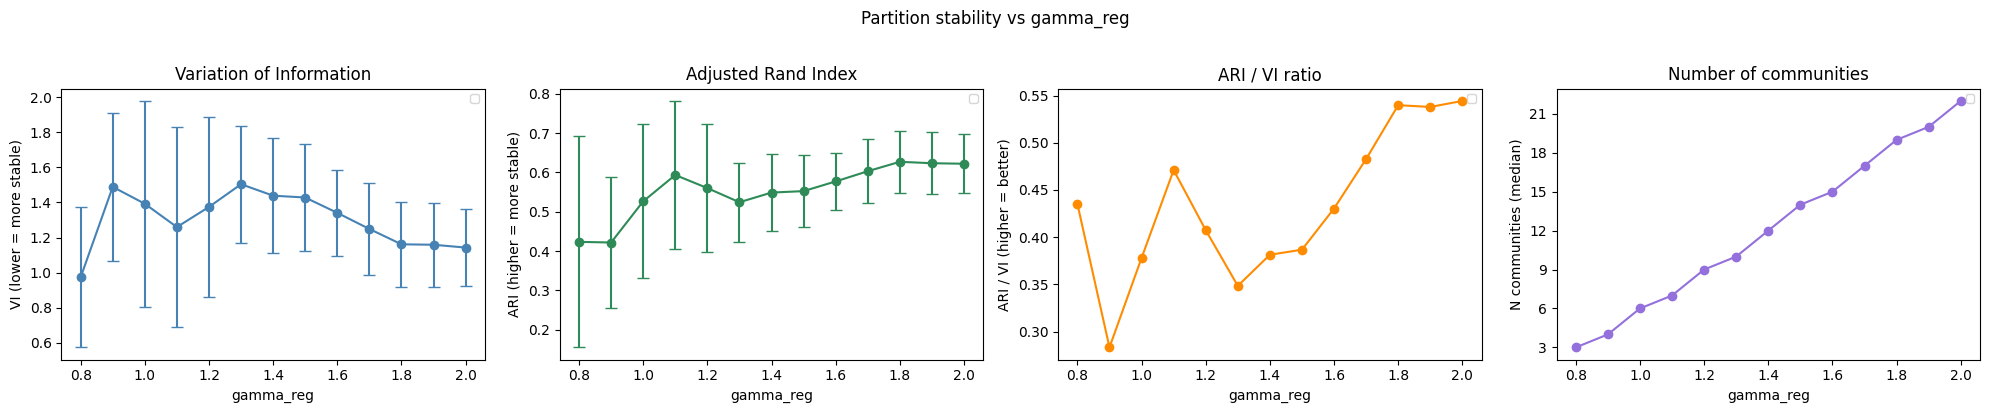

Saved: ../../../data/real/Norman2019/GRN/figures/stability_vs_gamma.png / .svg
   gamma    VI_mean    VI_std    ARI_mean    ARI_std    ARI/VI   n_comm
------------------------------------------------------------------------
     0.8      0.973     0.400       0.423      0.268     0.435        3
     0.9      1.489     0.425       0.422      0.166     0.283        4
     1.0      1.393     0.587       0.526      0.196     0.378        6
     1.1      1.260     0.573       0.593      0.188     0.471        7
     1.2      1.375     0.516       0.560      0.163     0.407        9
     1.3      1.504     0.334       0.524      0.101     0.348       10
     1.4      1.439     0.328       0.549      0.099     0.381       12
     1.5      1.428     0.306       0.552      0.092     0.387       14
     1.6      1.341     0.245       0.577      0.074     0.430       15
     1.7      1.249     0.262       0.603      0.082     0.483       17
     1.8      1.161     0.243       0.627      0.079    

In [14]:
# Stability diagnostics: VI, ARI, ARI/VI, and n_communities vs gamma_reg
# -----------------------------------------------------------------------
# VI decreases and ARI increases as gamma grows — if both move monotonically
# all the way to the grid edge, the best gamma is just the coarsest partition,
# not a genuinely stable one. Look for an elbow where improvement slows down.
# n_communities is the median number of communities across seeds (after filtering).

gammas    = sorted(stability.keys())
vi_means  = [stability[g]['VI_mean']  for g in gammas]
vi_stds   = [stability[g]['VI_std']   for g in gammas]
ari_means = [stability[g]['ARI_mean'] for g in gammas]
ari_stds  = [stability[g]['ARI_std']  for g in gammas]
ratio     = [a / v if v > 0 else float('nan') for a, v in zip(ari_means, vi_means)]
n_comms   = [int(np.median([len(set(m)) for m in filtered_results[g]])) for g in gammas]

fig, axes = plt.subplots(1, 4, figsize=(20, 4))

# --- VI ---
axes[0].errorbar(gammas, vi_means, yerr=vi_stds,
                 marker='o', color='steelblue', capsize=4, lw=1.5)
axes[0].set_xlabel('gamma_reg')
axes[0].set_ylabel('VI (lower = more stable)')
axes[0].set_title('Variation of Information')
axes[0].legend(fontsize=8)

# --- ARI ---
axes[1].errorbar(gammas, ari_means, yerr=ari_stds,
                 marker='o', color='seagreen', capsize=4, lw=1.5)
axes[1].set_xlabel('gamma_reg')
axes[1].set_ylabel('ARI (higher = more stable)')
axes[1].set_title('Adjusted Rand Index')
axes[1].legend(fontsize=8)

# --- ARI / VI ---
axes[2].plot(gammas, ratio, marker='o', color='darkorange', lw=1.5)
axes[2].set_xlabel('gamma_reg')
axes[2].set_ylabel('ARI / VI (higher = better)')
axes[2].set_title('ARI / VI ratio')
axes[2].legend(fontsize=8)

# --- n_communities ---
axes[3].plot(gammas, n_comms, marker='o', color='mediumpurple', lw=1.5)
axes[3].set_xlabel('gamma_reg')
axes[3].set_ylabel('N communities (median)')
axes[3].set_title('Number of communities')
axes[3].yaxis.set_major_locator(plt.MaxNLocator(integer=True))
axes[3].legend(fontsize=8)

plt.suptitle('Partition stability vs gamma_reg', y=1.02)
plt.tight_layout()
save_figure(fig, 'stability_vs_gamma')

# Summary table
print(f"{'gamma':>8}  {'VI_mean':>9}  {'VI_std':>8}  {'ARI_mean':>10}  {'ARI_std':>9}  {'ARI/VI':>8}  {'n_comm':>7}")
print('-' * 72)
for g, vm, vs, am, as_, r, nc in zip(gammas, vi_means, vi_stds, ari_means, ari_stds, ratio, n_comms):
    marker = ''
    r_str = f'{r:>8.3f}' if not (r != r) else '     nan'  # handle nan
    print(f"{g:>8.1f}  {vm:>9.3f}  {vs:>8.3f}  {am:>10.3f}  {as_:>9.3f}  {r_str}  {nc:>7d}{marker}")


In [28]:
# Consensus clustering with best_key set in control parameters
print("Best hyperparams (gamma_reg):", best_key)
print("Best stability stats:", stability[best_key])

# 6. Consensus clustering: majority vote after label alignment
memberships_list = filtered_results[best_key]
C = build_coassociation_matrix(memberships_list)
consensus_labels, agreement = consensus_partition_majority_vote(memberships_list)

# 7. Diagnostics for g_reg layer only
df_reg_stats = community_stats(g_reg, consensus_labels)

print("Regulatory layer community stats:")
print(df_reg_stats.to_string(index=False))

print(f"\nNode agreement stats (fraction of runs matching consensus label):")
print(f"  mean={agreement.mean():.3f}  min={agreement.min():.3f}  "
      f"n_below_0.5={(agreement < 0.5).sum()}")


Best hyperparams (gamma_reg): 1.1
Best stability stats: {'VI_mean': np.float64(1.2596505437607322), 'VI_std': np.float64(0.5727915187236198), 'ARI_mean': np.float64(0.5933970731419724), 'ARI_std': np.float64(0.1883455314027615), 'n_pairs': 200}
Regulatory layer community stats:
 community  size  density  num_internal_edges  num_boundary_edges  w_internal  w_boundary  w_ratio
         5    30 0.565517                 246                1432    1.276215    4.954075 0.204840
         1    27 0.578348                 203                1272    1.534594    5.086632 0.231769
         2    21 0.333333                  70                 874    0.546781    3.269659 0.143270
         3    20 0.563158                 107                 957    1.133006    5.060774 0.182926
         4    20 0.526316                 100                 936    1.262662    5.019571 0.200989
         0    14 0.483516                  44                 649    0.917559    3.679318 0.199605
         6     9 0.527778   

In [29]:
# Count elements per cluster
counts = pd.DataFrame({"consensus_labels": consensus_labels})["consensus_labels"].value_counts().to_dict()

# Identify small clusters
small_clusters = {lab for lab, cnt in counts.items() if cnt < min_size}

# Replace small clusters with the minimum label
if len(list(small_clusters)) > 0:
    min_label = int(np.min(np.array(list(small_clusters))))
    consensus_labels = np.where(np.isin(consensus_labels, list(small_clusters)), min_label, consensus_labels)

# Diagnostics for g_reg layer only
df_reg_stats = community_stats(g_reg, consensus_labels)

print("Regulatory layer community stats after merging small clusters:")
print(df_reg_stats.to_string(index=False))


Regulatory layer community stats after merging small clusters:
 community  size  density  num_internal_edges  num_boundary_edges  w_internal  w_boundary  w_ratio
         5    30 0.565517                 246                1432    1.276215    4.954075 0.204840
         1    27 0.578348                 203                1272    1.534594    5.086632 0.231769
         2    21 0.333333                  70                 874    0.546781    3.269659 0.143270
         3    20 0.563158                 107                 957    1.133006    5.060774 0.182926
         4    20 0.526316                 100                 936    1.262662    5.019571 0.200989
         0    14 0.483516                  44                 649    0.917559    3.679318 0.199605
         6     9 0.527778                  19                 424    0.118303    1.349363 0.080606


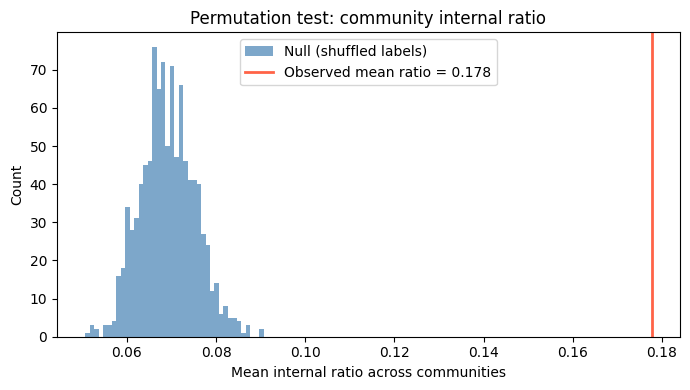

Saved: ../../../data/real/Norman2019/GRN/figures/permutation_test_internal_ratio.png / .svg
Observed mean ratio : 0.1777
Null mean ± std     : 0.0692 ± 0.0061
Permutation p-value : 0.0000  (0/1000 null >= observed)


In [30]:
# Permutation test for community internal ratio
# -----------------------------------------------
# Shuffle consensus_labels n_perm times and recompute the mean ratio across
# communities. If the observed mean ratio is well above the null distribution,
# the communities carry genuine regulatory coherence beyond what is expected
# by chance given their sizes.

n_perm = 1000
rng    = np.random.default_rng(42)

df_obs   = community_stats(g_reg, consensus_labels)
obs_mean = df_obs['w_ratio'].mean()

null_means = []
for _ in range(n_perm):
    shuffled = rng.permutation(consensus_labels)
    null_means.append(community_stats(g_reg, shuffled)['w_ratio'].mean())

null_means = np.array(null_means)
p_value    = (null_means >= obs_mean).mean()

fig, ax = plt.subplots(figsize=(7, 4))
ax.hist(null_means, bins=40, color='steelblue', alpha=0.7, label='Null (shuffled labels)')
ax.axvline(obs_mean, color='tomato', lw=2, label=f'Observed mean ratio = {obs_mean:.3f}')
ax.set_xlabel('Mean internal ratio across communities')
ax.set_ylabel('Count')
ax.set_title('Permutation test: community internal ratio')
ax.legend()
plt.tight_layout()
save_figure(fig, 'permutation_test_internal_ratio')

print(f"Observed mean ratio : {obs_mean:.4f}")
print(f"Null mean ± std     : {null_means.mean():.4f} ± {null_means.std():.4f}")
print(f"Permutation p-value : {p_value:.4f}  ({int(p_value * n_perm)}/{n_perm} null >= observed)")


In [31]:
# saving
_top_pct = int(top_percentage * 100)
_gamma = str(best_key).replace('.', 'p')
with open(results_folder + f'consensus_labels_{_top_pct}pct_gamma{_gamma}.pkl', 'wb') as f:
    pickle.dump(consensus_labels, f)

In [32]:
# Save TF community assignments
tf_communities = pd.DataFrame({
    'community': consensus_labels,
    'tf': tf_names,
}).sort_values(['community', 'tf']).reset_index(drop=True)

_top_pct = int(top_percentage * 100)
_gamma = str(best_key).replace('.', 'p')
fname = f'tf_communities_{_top_pct}pct_gamma{_gamma}.csv'
tf_communities.to_csv(results_folder + fname, index=False)
print(f'Saved {len(tf_communities)} TFs → {results_folder}{fname}')
print(tf_communities.groupby('community').size().rename('n_tfs').to_string())

Saved 141 TFs → ../../../data/real/Norman2019/GRN/tf_communities_100pct_gamma1p1.csv
community
0    14
1    27
2    21
3    20
4    20
5    30
6     9


## Network visualization

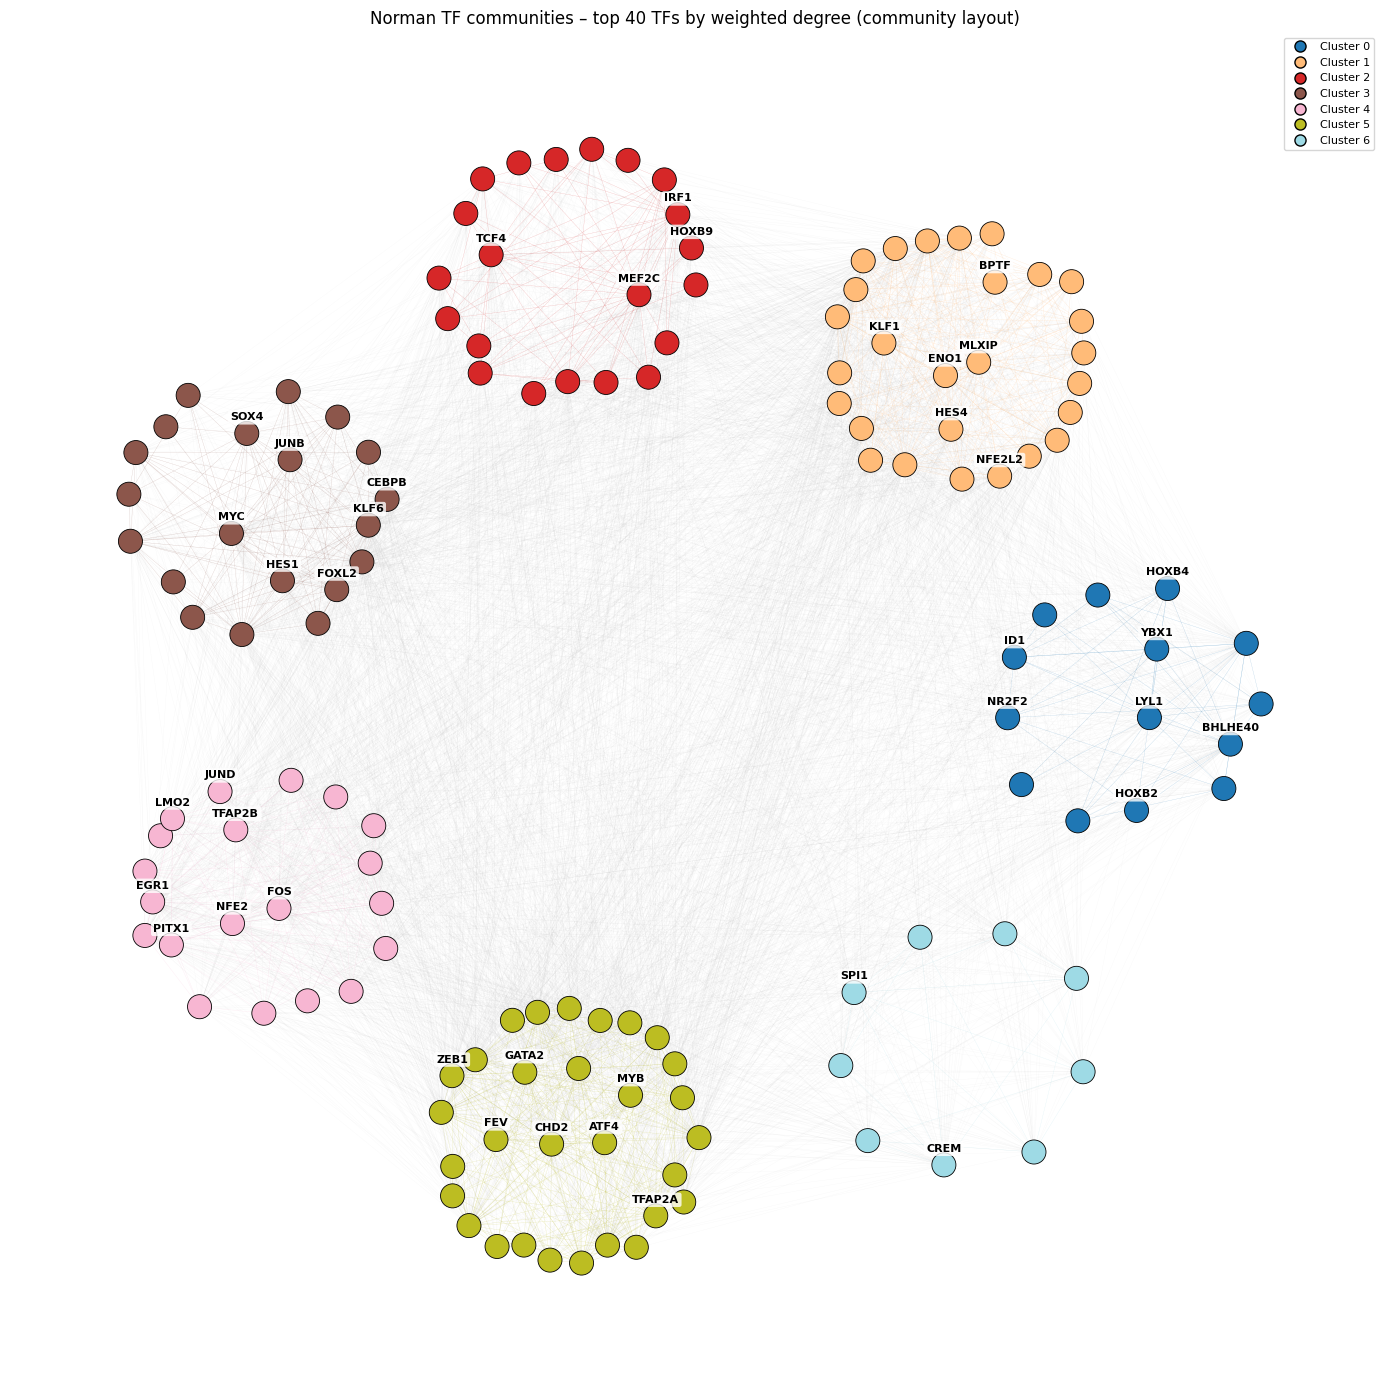

Saved: ../../../data/real/Norman2019/GRN/figures/tf_communities_labeled.png / .svg


In [33]:
# Labeled view: top 40 TFs by weighted degree
G_vis, pos_vis = plot_tf_tf_communities(
    current_grn=current_grn,
    tf_names=tf_names,
    consensus_labels=consensus_labels,
    layout='community',
    k=0.7,
    seed=42,
    figsize=(14, 14),
    node_size=300,
    with_labels=False,
    label_top_n_degree=40,
    edge_alpha_intra=0.35,
    edge_alpha_inter=0.08,
    edge_width_scale=2.0,
    title='Norman TF communities – top 40 TFs by weighted degree (community layout)',
    show=False,
    hide_isolates=True,
)
save_figure(plt.gcf(), 'tf_communities_labeled')


## Gene set enrichment analysis

In [34]:
# 1) Build per-cluster gene sets (TFs + targets)
cluster2genes = build_cluster_gene_sets(
    tf_names=tf_names,
    consensus_labels=consensus_labels,
    current_grn=current_grn,
)

# 2) Load GO BP gene sets (Homo sapiens)
# gseapy 1.1.11 bug: iter_lines(decode_unicode="utf-8") silently returns bytes;
# work around by decoding manually via response.text / requests directly.
_lib_name = 'GO_Biological_Process_2025'
_cache_file = os.path.join(DEFAULT_CACHE_PATH, f'Enrichr.{_lib_name}.gmt')

if os.path.isfile(_cache_file):
    raw_go_bp = {}
    with open(_cache_file) as _f:
        for _line in _f:
            _entries = _line.strip().split('\t')
            raw_go_bp[_entries[0]] = _entries[2:]
    print(f'Loaded GO library from cache: {_cache_file}')
else:
    _url = (f'http://maayanlab.cloud/Enrichr/geneSetLibrary'
            f'?mode=text&libraryName={_lib_name}')
    _resp = requests.get(_url, timeout=None, stream=True)
    if not _resp.ok:
        raise RuntimeError(f'Failed to download {_lib_name}: {_resp.status_code}')
    raw_go_bp = {}
    os.makedirs(DEFAULT_CACHE_PATH, exist_ok=True)
    with open(_cache_file, 'w') as _out:
        for _line in _resp.iter_lines(chunk_size=1024):
            if isinstance(_line, bytes):
                _line = _line.decode('utf-8')
            _parts = _line.strip().split('\t')
            _k = _parts[0]
            _v = [x.split(',')[0] for x in _parts[2:] if x.split(',')[0]]
            raw_go_bp[_k] = _v
            _out.write('\t\t'.join([_k, '\t'.join(_v)]) + '\n')
    print(f'Downloaded and cached GO library → {_cache_file}')

print(f'GO BP terms loaded: {len(raw_go_bp)}')

# 2.1) Extract GO IDs present in this library
go_ids_in_library = extract_go_ids_from_terms(raw_go_bp)

# 2.2) Compute levels only for these GO IDs (BP namespace)
# Note: go_obo_path is optional - defaults to gCRL/data/reference/ontologies/go-basic.obo
go_term_levels = compute_go_levels(
    go_ids=go_ids_in_library,
    namespace="biological_process",
)

Loaded GO library from cache: /home/laganiv/.cache/gseapy/Enrichr.GO_Biological_Process_2025.gmt
GO BP terms loaded: 5343
Loading GO DAG from /home/laganiv/Desktop/projects/CausalEmbed/grn_crl/gCAL/gCRL/data/reference/ontologies/go-basic.obo ...
/home/laganiv/Desktop/projects/CausalEmbed/grn_crl/gCAL/gCRL/data/reference/ontologies/go-basic.obo: fmt(1.2) rel(2025-10-10) 42,666 Terms


In [35]:
# 3) Filter GO BP by size and (optionally) level
go_bp_filtered = filter_gene_sets_by_size_and_level(
    gene_sets=raw_go_bp,
    min_size=20,               # min genes per GO term
    max_size=200,              # max genes per GO term
    go_term_levels=go_term_levels,
    min_level=5,               # example: only level >= 4
    max_level=None,            # or e.g. 5 if you want 4–5 only
)
len(go_bp_filtered)

1484

In [36]:
# 4) Run ORA
# universe_mode controls the background population N for the hypergeometric test:
#   'grn'    — GRN genes only (~700): biologically precise, but can be too small
#              when cluster gene-sets cover >50% of the universe (BH kills all results)
#   'custom' — arbitrary gene list via custom_universe= (recommended: pass hvg_names,
#              the 5,000 HVGs — larger than GRN, smaller than GO library,
#              and tied to the genes actually measured in this experiment)
#   'go'     — all GO library genes (~11k): maximum power but inflates
#              housekeeping terms (e.g. myeloid/erythroid differentiation in K562)
ora_results = run_ora_for_clusters(
    cluster2genes=cluster2genes,
    gene_sets=go_bp_filtered,
    universe_mode='go',
    custom_universe=hvg_names,
    min_genes_in_cluster=5,
)

print(f'Total ORA rows: {len(ora_results)}')
print(f'Rows with FDR < 0.05: {(ora_results["pval_adj"] < 0.05).sum()}')
print(f'Clusters with ≥1 significant term: {sorted(ora_results[ora_results["pval_adj"] < 0.05]["cluster_id"].unique())}')


Universe mode: 'go'  →  N = 11,748 genes
Total ORA rows: 9936
Rows with FDR < 0.05: 1312
Clusters with ≥1 significant term: [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6)]


In [37]:
# 5) Flag cell-line background terms
# Terms significantly enriched in >50% of clusters are likely housekeeping
# biology (e.g. myeloid/erythroid differentiation), not cluster-specific signal.
ora_results = filter_cluster_specific_terms(
    ora_results,
    fdr_threshold=0.05,
    max_cluster_fraction=0.5,
)

bg_terms = ora_results[ora_results['background_term']]['go_term'].unique()
print(f'Flagged background terms ({len(bg_terms)}):')
for t in sorted(bg_terms):
    print(f'  {prettify_go_term(t)}')

# Retain only cluster-specific terms for downstream analysis
filtered_ora_results = ora_results[~ora_results['background_term']].copy()

# Save all three artefacts with consistent naming
_top_pct = int(top_percentage * 100)
_gamma   = str(best_key).replace('.', 'p')
_stem    = f'{_top_pct}pct_gamma{_gamma}'

# Full ORA results (includes background_term flag column)
ora_results.to_csv(results_folder + f'ora_results_{_stem}.csv', index=False)
with open(results_folder + f'ora_results_{_stem}.pkl', 'wb') as f:
    pickle.dump(ora_results, f)

# Filtered ORA results (background terms removed)
filtered_ora_results.to_csv(results_folder + f'ora_results_filtered_{_stem}.csv', index=False)
with open(results_folder + f'ora_results_filtered_{_stem}.pkl', 'wb') as f:
    pickle.dump(filtered_ora_results, f)

# Background terms (plain text list)
with open(results_folder + f'ora_background_terms_{_stem}.txt', 'w') as f:
    f.write('\n'.join(sorted(bg_terms)))

print(f'Saved:')
print(f'  ora_results_{_stem}.csv / .pkl  ({len(ora_results):,} rows)')
print(f'  ora_results_filtered_{_stem}.csv / .pkl  ({len(filtered_ora_results):,} rows)')
print(f'  ora_background_terms_{_stem}.txt  ({len(bg_terms)} terms)')


filter_cluster_specific_terms: 7 clusters, FDR < 0.05, max_cluster_fraction = 0.5
  → 202 background terms flagged (significant in > 50% of clusters)
  → 8,522 rows retained
Flagged background terms (202):
  + Reg of Phosphatidylinositol 3-Kinase/Prot Kinase B Signal Transduction
  Actin Filament Organization
  Adenylate Cyclase-Activating G Protein-Coupled Receptor Signaling Pathway
  Antigen Processing and Presentation of Exogenous Peptide Antigen via MHC Class II
  B Cell Differentiation
  B Cell Receptor Signaling Pathway
  Calcium Ion Transport
  Calcium-Mediated Signaling
  Cardiac Muscle Cell Action Potential
  Cardiac Muscle Cell Action Potential Involved in Contraction
  Cardiac Muscle Contraction
  Cellular Response to Amyloid-Beta
  Cellular Response to Decreased Oxygen Levels
  Cellular Response to Lipopolysaccharide
  Cellular Response to Steroid Hormone Stimulus
  Cellular Response to Transforming Growth Factor Beta Stimulus
  Cellular Response to Tumor Necrosis Factor
  

In [38]:
# For each cluster, show top 5 enriched GO BP terms
for cluster_id in filtered_ora_results['cluster_id'].unique():
    print(f"\nCluster {cluster_id} top GO BP terms:")
    top_terms = filtered_ora_results[filtered_ora_results['cluster_id'] == cluster_id].sort_values(by='pval').head(10)
    for _, row in top_terms.iterrows():
        print(f"  {row['go_term']} (P-value: {row['pval']:.4e}), adj p-value: {row['pval_adj']:.4e})")


Cluster 0 top GO BP terms:
  Negative Regulation of Immune Response (GO:0050777) (P-value: 3.4553e-03), adj p-value: 3.4359e-02)
  Positive Regulation of Cell Junction Assembly (GO:1901890) (P-value: 3.8903e-03), adj p-value: 3.7378e-02)
  Regulation of Peptidyl-Tyrosine Phosphorylation (GO:0050730) (P-value: 3.9867e-03), adj p-value: 3.8048e-02)
  Prostanoid Metabolic Process (GO:0006692) (P-value: 4.1424e-03), adj p-value: 3.8250e-02)
  Positive Regulation of Fibroblast Proliferation (GO:0048146) (P-value: 4.3802e-03), adj p-value: 3.9422e-02)
  Negative Regulation of Endocytosis (GO:0045806) (P-value: 5.5443e-03), adj p-value: 4.7384e-02)
  Ventricular Cardiac Muscle Tissue Development (GO:0003229) (P-value: 5.5648e-03), adj p-value: 4.7384e-02)
  Positive Regulation of Cytoskeleton Organization (GO:0051495) (P-value: 6.3126e-03), adj p-value: 5.2803e-02)
  Negative Regulation of Myeloid Leukocyte Differentiation (GO:0002762) (P-value: 6.9372e-03), adj p-value: 5.7248e-02)
  Regula

### GO enrichment dotplots

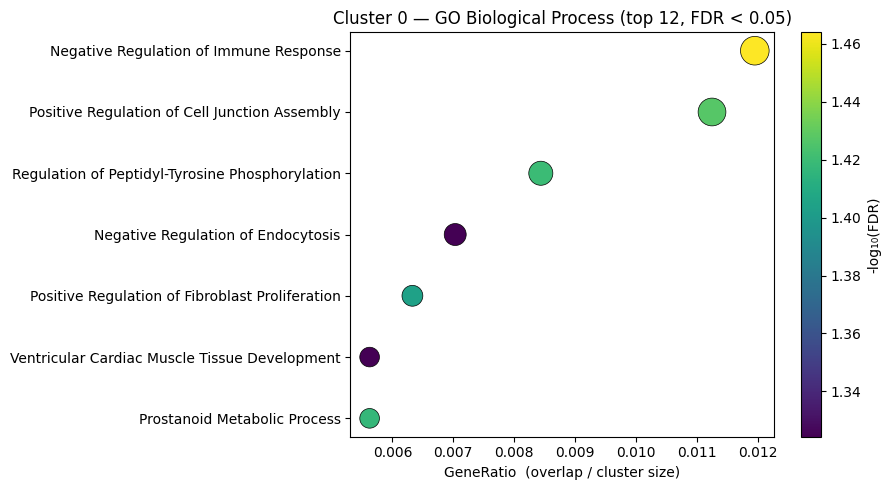

Saved: ../../../data/real/Norman2019/GRN/figures/dotplot_cluster0_100pct_gamma1p1.png / .svg


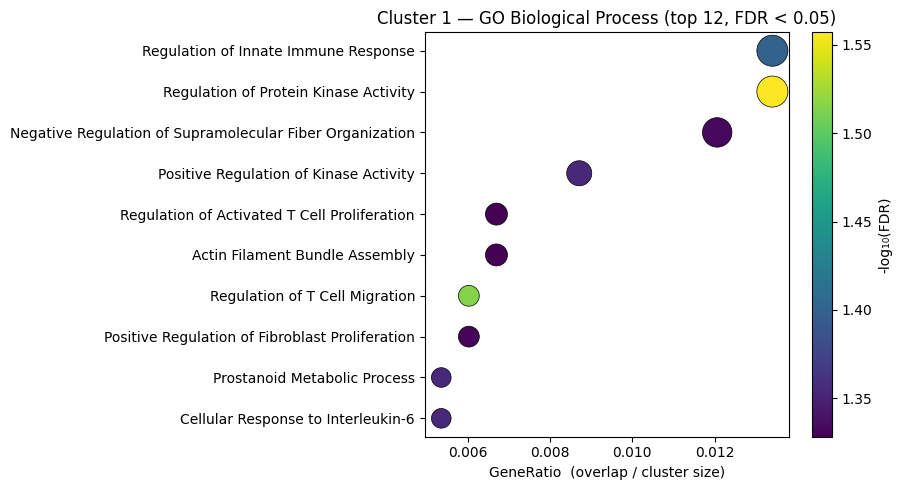

Saved: ../../../data/real/Norman2019/GRN/figures/dotplot_cluster1_100pct_gamma1p1.png / .svg


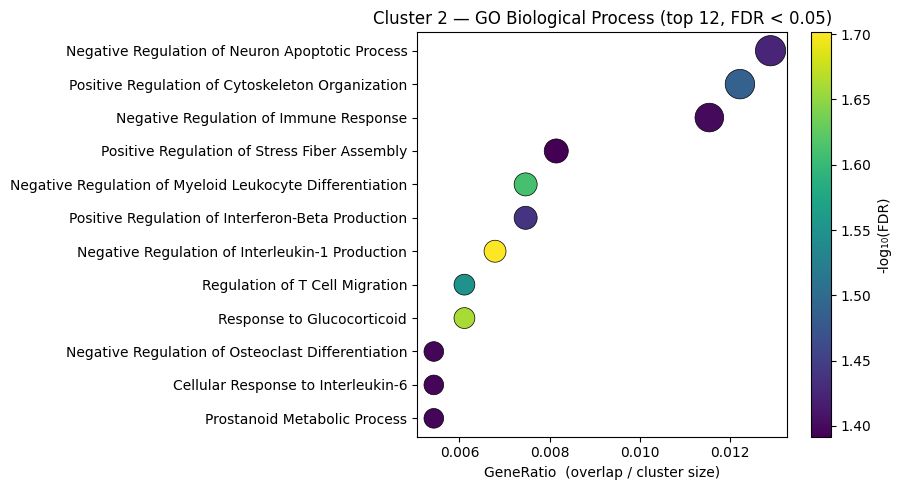

Saved: ../../../data/real/Norman2019/GRN/figures/dotplot_cluster2_100pct_gamma1p1.png / .svg


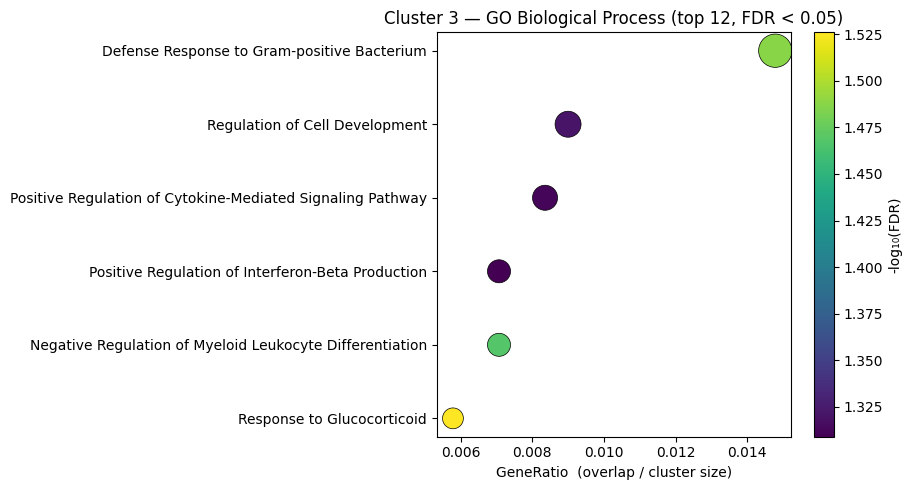

Saved: ../../../data/real/Norman2019/GRN/figures/dotplot_cluster3_100pct_gamma1p1.png / .svg


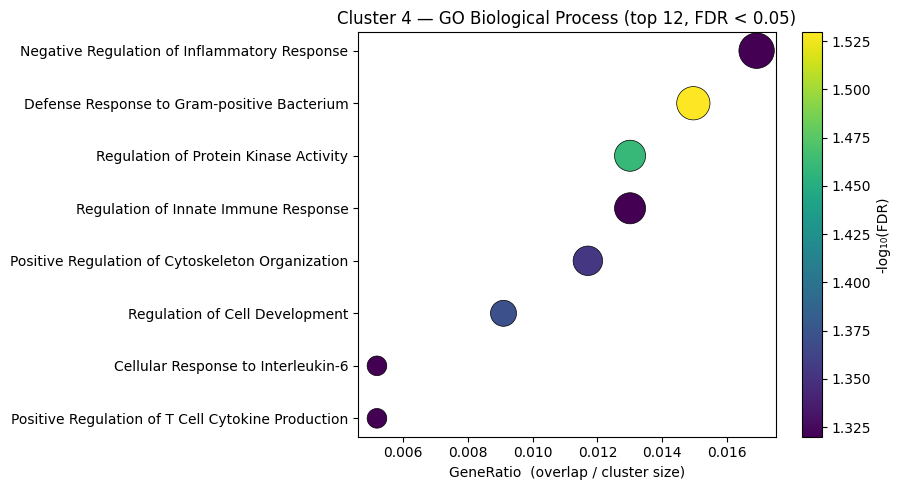

Saved: ../../../data/real/Norman2019/GRN/figures/dotplot_cluster4_100pct_gamma1p1.png / .svg


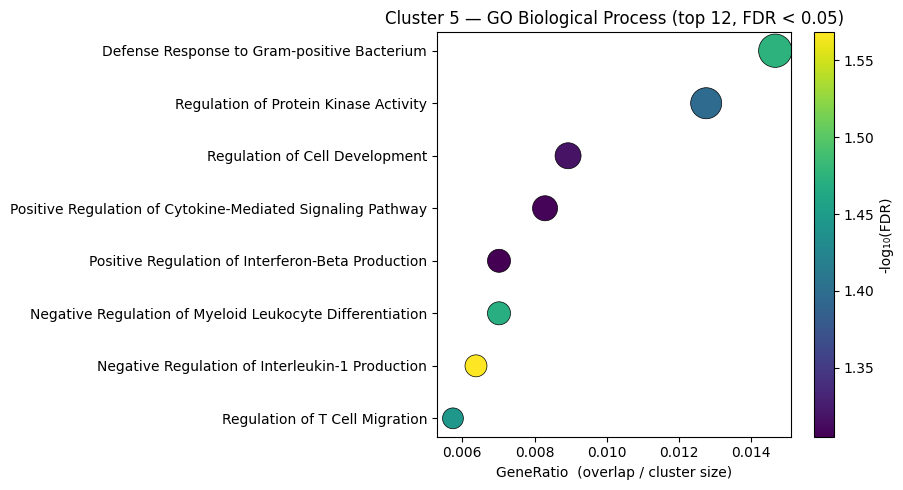

Saved: ../../../data/real/Norman2019/GRN/figures/dotplot_cluster5_100pct_gamma1p1.png / .svg


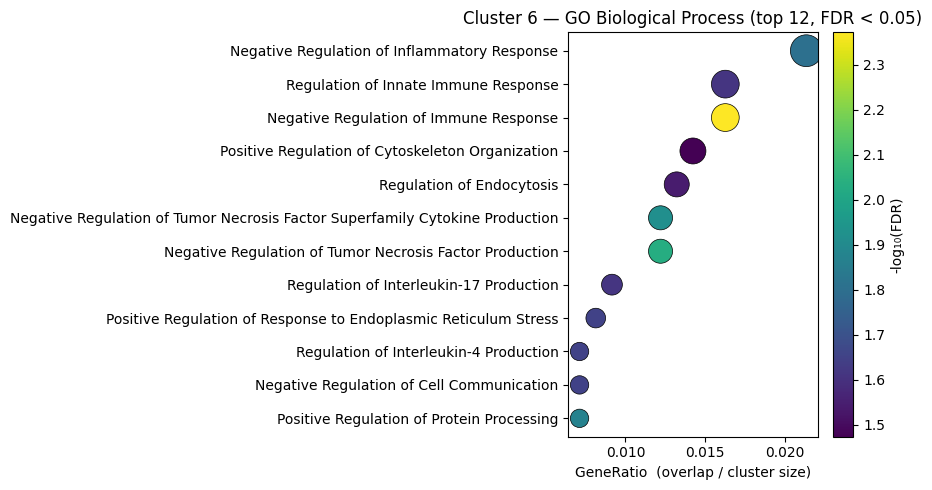

Saved: ../../../data/real/Norman2019/GRN/figures/dotplot_cluster6_100pct_gamma1p1.png / .svg


In [39]:
# One dotplot per cluster (significant, cluster-specific terms only)
sig_results = filtered_ora_results[(filtered_ora_results['pval_adj'] < 0.05)]

_top_pct = int(top_percentage * 100)
_gamma   = str(best_key).replace('.', 'p')
_stem    = f'{_top_pct}pct_gamma{_gamma}'

for cluster_id in sorted(sig_results['cluster_id'].unique()):
    n_terms = (sig_results['cluster_id'] == cluster_id).sum()
    if n_terms == 0:
        continue
    fig, ax = plot_enrichment_dotplot(
        enrich_df=sig_results,
        cluster_id=cluster_id,
        top_n=12,
        term_parser=prettify_go_term,
        figsize=(9, 5),
        title=f'Cluster {cluster_id} — GO Biological Process (top 12, FDR < 0.05)',
        show=False,
    )
    save_figure(fig, f'dotplot_cluster{cluster_id}_{_stem}')
